In [1]:
from langgraph.graph import StateGraph, MessagesState, START
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
# Load environment variables from .env file
load_dotenv()

True

In [3]:
# define the hugging face endpoint
llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct",
    task="text-generation",
    max_new_tokens=2048,
)

# define the model
model = ChatHuggingFace(llm=llm)

In [5]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages" : [response]}

In [6]:
# define the graph
graph = StateGraph(MessagesState)
graph.add_node("call_model", call_model)
graph.add_edge(START, "call_model")

In [7]:
workflow = graph.compile()

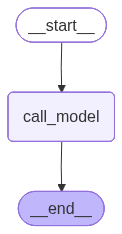

In [8]:
workflow

In [9]:
workflow.invoke({"messages" : {"role": "user", "content": "My name is Ayush"}})

{'messages': [HumanMessage(content='My name is Ayush', additional_kwargs={}, response_metadata={}, id='26eb3d8e-a679-4b54-8596-0fdaea9f8bd9'),
  AIMessage(content='Hello Ayush! Nice to meet you. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 34, 'total_tokens': 51}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019daa27-b6ff-78b2-b99f-240e0d6faa0c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 34, 'output_tokens': 17, 'total_tokens': 51})]}

In [10]:
workflow.invoke({"messages" : {"role": "user", "content": "What is my name ?"}})

{'messages': [HumanMessage(content='What is my name ?', additional_kwargs={}, response_metadata={}, id='40149979-718d-423c-8a18-5b57b4642518'),
  AIMessage(content='You didn\'t provide your name in your message. In our conversation, you can tell me your name if you\'d like me to use it! Otherwise, I can continue to address you as "user" or simply by using your preferred form of address.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 34, 'total_tokens': 86}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019daa27-f7db-78e1-8d60-f26046298d81-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 34, 'output_tokens': 52, 'total_tokens': 86})]}

Here, we can see that the memory in llms is not intrinsic, i.e. each llm call is independent and they can't remember anything without explicitly adding memory into it.

Next, we will see how we can add persistence to the state so that the llm remembers our past memory as well

#### STM with In Memory Persistence

In [11]:
from langgraph.checkpoint.memory import InMemorySaver 
checkpointer = InMemorySaver()
workflow2 = graph.compile(checkpointer=checkpointer)

In [13]:
thread1 = {"configurable": {"thread_id": "thread1"}}
workflow2.invoke({"messages" : {"role": "user", "content": "My name is Ayush"}}, config=thread1)

{'messages': [HumanMessage(content='My name is Ayush', additional_kwargs={}, response_metadata={}, id='a38982af-8b15-4186-a086-2e25f3cddaee'),
  AIMessage(content="Hello Ayush! Nice to meet you. How can I assist you today? Do you have any specific questions or topics you'd like to discuss?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 34, 'total_tokens': 65}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019daa2c-9fe6-7123-8cf1-3187667f3952-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 34, 'output_tokens': 31, 'total_tokens': 65})]}

In [15]:
workflow2.invoke({"messages" : {"role": "user", "content": "What is my name ?"}}, config=thread1)

{'messages': [HumanMessage(content='My name is Ayush', additional_kwargs={}, response_metadata={}, id='a38982af-8b15-4186-a086-2e25f3cddaee'),
  AIMessage(content="Hello Ayush! Nice to meet you. How can I assist you today? Do you have any specific questions or topics you'd like to discuss?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 34, 'total_tokens': 65}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019daa2c-9fe6-7123-8cf1-3187667f3952-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 34, 'output_tokens': 31, 'total_tokens': 65}),
  HumanMessage(content='What is my name ?', additional_kwargs={}, response_metadata={}, id='78657a3b-d7ed-41d7-82cf-6605a754b91e'),
  AIMessage(content='Your name is Ayush.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 7, 'prompt_tokens': 79, 'total_tokens': 86}, '

In [16]:
thread2 = {"configurable": {"thread_id": "thread2"}}
workflow2.invoke({"messages" : {"role": "user", "content": "What is my name ?"}}, config=thread2)

{'messages': [HumanMessage(content='What is my name ?', additional_kwargs={}, response_metadata={}, id='1cd3c593-402d-46e9-95a3-273e524995e6'),
  AIMessage(content="You didn't provide your name in your question. Since you're asking what your name is, I don't have that information. If you tell me your name, I'd be happy to confirm it!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 34, 'total_tokens': 76}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019daa2d-b18b-7bc2-864d-6bbe77b4ae29-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 34, 'output_tokens': 42, 'total_tokens': 76})]}

In [21]:
snap = workflow2.get_state(thread1)
vals = snap.values
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

- HumanMessage : My name is Ayush
- AIMessage : Hello Ayush! Nice to meet you. How can I assist you today? Do you have any specific questions or topics you'd like to discuss?
- HumanMessage : What is my name ?
- AIMessage : Your name is Ayush.
